# Weekend Project: Chaos-to-Clarity Extractor (C2C)

**Objective:** Fine-tune Gemma 4 E4B-it to extract structured action items from messy text.

*Note: "it" stands for "instruction tuned" which means the model has been tuned for following instructions*

## Import Dependencies

In [1]:
import warnings
warnings.filterwarnings("ignore")
# !pip install git+https://github.com/huggingface/transformers.git -U

!pip install -U huggingface_hub datasets transformers accelerate trl peft bitsandbytes -q
!pip install -U evaluate rouge_score nltk gradio matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 12.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 99.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 88.1 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.8/36.8 MB 56.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 3.9 MB/s eta 0:00:00
 

In [2]:
import transformers
import trl
import datasets
import accelerate

import gradio as gr
import torch

from pathlib import Path
import json
import yaml

In [3]:
import os
os.environ["C2C_PUSH_TO_HUB"] = "1"
os.environ["C2C_HUB_MODEL_ID"] = "raqibcodes/c2c-checkpoints"
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

'0'

In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [5]:
from huggingface_hub import hf_hub_download
import shutil
import os

# 1. Download from HF to a temporary cache
file_path = hf_hub_download(repo_id="raqibcodes/c2c-checkpoints", filename="checkpoint.zip")

# 2. Move it to your current working directory
shutil.copy(file_path, "/kaggle/working/checkpoint.zip")

# 3. Unzip it so your training script can find the weights
os.system("unzip -q /kaggle/working/checkpoint.zip -d /kaggle/working/")

print("Checkpoints restored. Ready to resume training!")

checkpoint.zip:   0%|          | 0.00/534M [00:00<?, ?B/s]

Checkpoints restored. Ready to resume training!


In [6]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(hf_token)

In [7]:
# Check the amount of GPU memory available (we need at least ~16GB)
import torch

if torch.cuda.is_available():
    device = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(device)

    total_memory = torch.cuda.get_device_properties(device).total_memory
    allocated_memory = torch.cuda.memory_allocated(device)
    reserved_memory = torch.cuda.memory_reserved(device)
    free_memory = total_memory - reserved_memory

    print(f"GPU: {gpu_name}")
    print(f"Total Memory:     {total_memory / 1e6:.2f} MB | {total_memory / 1e9:.2f} GB")
    print(f"Allocated Memory: {allocated_memory / 1e6:.2f} MB | {allocated_memory / 1e9:.2f} GB")
    print(f"Reserved Memory:  {reserved_memory / 1e6:.2f} MB | {reserved_memory / 1e9:.2f} GB")
    print(f"Free Memory:      {free_memory / 1e6:.2f} MB | {free_memory / 1e9:.2f} GB")
else:
    print("No CUDA GPU available")

GPU: Tesla T4
Total Memory:     15637.09 MB | 15.64 GB
Allocated Memory: 0.00 MB | 0.00 GB
Reserved Memory:  0.00 MB | 0.00 GB
Free Memory:      15637.09 MB | 15.64 GB


## Setup Base model

In [8]:
# Optional smoke test: full-precision load (needs a big GPU — skip on Colab T4).
# For real training, use the QLoRA cell later instead of running this.
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "google/gemma-4-E4B-it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Uncomment only if you have enough VRAM (not required for the QLoRA path below):
# model = AutoModelForCausalLM.from_pretrained(
#     MODEL_NAME,
#     device_map="auto",
#     torch_dtype=torch.bfloat16,
#     attn_implementation="eager",
# )

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

## Setup and Format Dataset
This step converts our raw synthetic `.jsonl` files into structured Hugging Face Dataset objects. First, we load the raw messy text and the clean YAML labels from our files. Then, we use the Gemma 4 tokenizer to map these pairs into a strict conversational template. By wrapping our data in specific control tokens (like <bos> and <|turn|>), we format the inputs and outputs into the exact "language" the model was originally trained to understand.

In [9]:
def load_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


# colab
# train_path = Path("/content/data/train.jsonl")
# test_path = Path("/content/data/test.jsonl")

# kaggle
train_path = Path("/kaggle/input/datasets/abdulraqibomotosho/c2c-data/train.jsonl")
test_path = Path("/kaggle/input/datasets/abdulraqibomotosho/c2c-data/test.jsonl")

assert train_path.exists(), f"Missing {train_path.resolve()}"
assert test_path.exists(), f"Missing {test_path.resolve()}"

train_rows = load_jsonl(train_path)
test_rows = load_jsonl(test_path)

print(f"Train rows: {len(train_rows)}")
print(f"Test rows: {len(test_rows)}")

Train rows: 800
Test rows: 200


In [10]:
import random

sample = random.choice(train_rows)
print("Messy text:\n")
print(sample["text"])

print("\nYAML label:\n")
print(sample["label"])

print("\nParsed label object:\n")
yaml.safe_load(sample["label"])

Messy text:

quick ops brain dump ; confirm the client kickfof agneda for me by Friday EOD ; one more check procurement on laptop order for sales by next Monday morning not urgent ; calendar is a mess this week ; if possible ...

YAML label:

is_act: 1
intent: schedule
tasks:
- act: confirm the client kickoff agenda
  who: me
  due: Friday EOD
  pri: M
- act: check procurement on laptop order
  who: sales
  due: next Monday morning
  pri: L

Parsed label object:



{'is_act': 1,
 'intent': 'schedule',
 'tasks': [{'act': 'confirm the client kickoff agenda',
   'who': 'me',
   'due': 'Friday EOD',
   'pri': 'M'},
  {'act': 'check procurement on laptop order',
   'who': 'sales',
   'due': 'next Monday morning',
   'pri': 'L'}]}

### Canonical Dataset Formatting Path
This is the single source of truth for formatting C2C data before training.

What this block does:
1. Converts raw JSONL rows into Hugging Face datasets.
2. Builds **TRL conversational prompt–completion** rows: `prompt` = user message (includes shared `C2C_INSTRUCTION` + messy `text` after `---`), `completion` = assistant YAML from `label`. This enables **completion-only loss** (train on assistant tokens only).
3. Outputs `train_ds` and `test_ds` with **`prompt` and `completion`** columns for `SFTTrainer`.

Inference must apply the same user-side wrapping via **`c2c_user_content`** in `predict_c2c`.

After this cell, all downstream training code should use only `train_ds` and `test_ds`.

In [11]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "google/gemma-4-E4B-it"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Shared instruction: must match inference in `predict_c2c` (via `c2c_user_content`).
C2C_INSTRUCTION = """You are a structured extractor for the Chaos-to-Clarity (C2C) task.

Output rules (mandatory):
- Respond with YAML only. No markdown fences, no prose, no bullet options, no explanations.
- Keys: is_act (0 or 1), intent (remind|schedule|log|notify), tasks (list).
- Each task must have: act, who, due, pri (H|M|L).
- If is_act is 0, tasks must be an empty list.

The user message after the '---' separator is messy human text to extract from."""


def c2c_user_content(raw_user_text: str) -> str:
    return f"{C2C_INSTRUCTION}\n\n---\n\n{raw_user_text.strip()}"


def apply_gemma_template(example):
    user_body = c2c_user_content(example["text"])
    # TRL prompt-completion (conversational): loss only on completion tokens → completion_mask in preprocessing.
    return {
        "prompt": [{"role": "user", "content": user_body}],
        "completion": [{"role": "assistant", "content": example["label"]}],
    }


hf_train = Dataset.from_list(train_rows)
hf_test = Dataset.from_list(test_rows)

print("Formatting Train Dataset...")
train_ds = hf_train.map(apply_gemma_template, remove_columns=hf_train.column_names)

print("Formatting Test Dataset...")
test_ds = hf_test.map(apply_gemma_template, remove_columns=hf_test.column_names)

assert len(train_ds) == 800, len(train_ds)
assert len(test_ds) == 200, len(test_ds)
assert "prompt" in train_ds.column_names and "completion" in train_ds.column_names

print("\n--- SAMPLE prompt (user message preview) ---")
print(train_ds[0]["prompt"][0]["content"][:800])
print("\n--- SAMPLE completion (assistant YAML preview) ---")
print(train_ds[0]["completion"][0]["content"][:800])

Formatting Train Dataset...


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Formatting Test Dataset...


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


--- SAMPLE prompt (user message preview) ---
You are a structured extractor for the Chaos-to-Clarity (C2C) task.

Output rules (mandatory):
- Respond with YAML only. No markdown fences, no prose, no bullet options, no explanations.
- Keys: is_act (0 or 1), intent (remind|schedule|log|notify), tasks (list).
- Each task must have: act, who, due, pri (H|M|L).
- If is_act is 0, tasks must be an empty list.

The user message after the '---' separator is messy human text to extract from.

---

quick persnoal reminder cloud ; pay the electricity bill for roommate by this weekend high prio ; and pay the electricity bill for Dad by next weeek ; one more set up a reminder for medication for Dad by tonight super important ; i also spilled coffee on my notes so this is chhaotic ; thx

--- SAMPLE completion (assistant YAML preview) ---
is_act: 1
intent: remind
tasks:
- act: pay the electricity bill
  who: roommate
  due: this weekend
  pri: H
- act: pay the electricity bill
  who: Dad
  due: next 

In [12]:
# Pre-training data quality gate (fail fast before GPU time)

import random

ALLOWED_INTENT = frozenset({"remind", "schedule", "log", "notify"})
ALLOWED_PRI = frozenset({"H", "M", "L"})


def validate_c2c_label_obj(obj) -> tuple[bool, str]:
    if not isinstance(obj, dict):
        return False, "root is not a dict"
    required = {"is_act", "intent", "tasks"}
    if not required.issubset(obj.keys()):
        return False, f"missing top-level keys (need {required}): {set(obj.keys())}"
    if obj["intent"] not in ALLOWED_INTENT:
        return False, f"intent not allowed: {obj['intent']!r}"
    if obj["is_act"] not in (0, 1):
        return False, f"is_act must be 0 or 1, got {obj['is_act']!r}"
    tasks = obj["tasks"]
    if not isinstance(tasks, list):
        return False, "tasks is not a list"
    if obj["is_act"] == 0 and len(tasks) != 0:
        return False, "is_act==0 but tasks not empty"
    for i, t in enumerate(tasks):
        if not isinstance(t, dict):
            return False, f"task {i} not a dict"
        task_req = {"act", "who", "due", "pri"}
        if not task_req.issubset(t.keys()):
            return False, f"task {i} missing keys (need {task_req}): {set(t.keys())}"
        if t["pri"] not in ALLOWED_PRI:
            return False, f"task {i} bad pri: {t['pri']!r}"
    return True, "ok"


def audit_labels(rows, sample_size=40, seed=42):
    rng = random.Random(seed)
    n = min(sample_size, len(rows))
    idxs = rng.sample(range(len(rows)), n)
    parse_ok = schema_ok = 0
    for i in idxs:
        label = rows[i]["label"]
        try:
            obj = yaml.safe_load(label)
            parse_ok += 1
        except Exception:
            continue
        ok, _ = validate_c2c_label_obj(obj)
        if ok:
            schema_ok += 1
    print(f"Sampled {n} rows")
    print(f"  YAML parse success: {parse_ok}/{n}")
    print(f"  Schema-valid:       {schema_ok}/{n}")
    return parse_ok == n and schema_ok == n


train_ok = audit_labels(train_rows, 50)
test_ok = audit_labels(test_rows, 50)
if not (train_ok and test_ok):
    print("WARNING: fix labels in JSONL before training.")
else:
    print("Quality gate: all sampled labels parse and match schema.")

Sampled 50 rows
  YAML parse success: 50/50
  Schema-valid:       50/50
Sampled 50 rows
  YAML parse success: 50/50
  Schema-valid:       50/50
Quality gate: all sampled labels parse and match schema.


## Fine-tuning our model

Same flow as the NVIDIA / mrdbourke scaffold ([`SFTConfig`](https://huggingface.co/docs/trl/main/en/sft_trainer#trl.SFTConfig) → [`SFTTrainer`](https://huggingface.co/docs/trl/main/en/sft_trainer#trl.SFTTrainer)): supervised pairs go into the trainer; here we add **4-bit QLoRA** so **Gemma 4 E4B** fits a **Colab T4**.

The dataset uses TRL **conversational `prompt` + `completion`** rows (not a single `text` column) so preprocessing builds a **`completion_mask`** and the collator trains with **loss only on assistant YAML tokens**. Use a recent **`trl`** (e.g. install from GitHub if Colab’s default lags).

In [13]:
import math
import os
import re
from pathlib import Path
import json

import torch

print("torch.cuda.device_count() =", torch.cuda.device_count(), "— expect 1 for this QLoRA recipe")

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer

try:
    from trl.trainer.sft_trainer import DataCollatorForLanguageModeling as _TRLMDataCollator
except ImportError:
    from trl import DataCollatorForLanguageModeling as _TRLMDataCollator

# Kaggle (and some broken CUDA contexts): transformers' caching_allocator_warmup calls cudaMemGetInfo and can raise
# AcceleratorError / illegal memory access before weights load. Skip the warmup — slightly slower load.
def _c2c_maybe_disable_cuda_alloc_warmup():
    force = os.environ.get("C2C_SKIP_CUDA_ALLOC_WARMUP", "").lower() in ("1", "true", "yes")
    on_kaggle = Path("/kaggle").exists()
    if not (force or on_kaggle):
        return
    import transformers.modeling_utils as _mu

    def _noop_caching_allocator_warmup(*_args, **_kwargs):
        return None

    _mu.caching_allocator_warmup = _noop_caching_allocator_warmup
    print(
        "Skipping transformers caching_allocator_warmup (Kaggle or C2C_SKIP_CUDA_ALLOC_WARMUP=1) "
        "to avoid cudaMemGetInfo / illegal memory access during 4-bit load."
    )


_c2c_maybe_disable_cuda_alloc_warmup()

# --- Fast checks before the ~10 min download + load ---
assert torch.cuda.is_available(), "Need a GPU runtime (CUDA not available)."
for _name in ("MODEL_NAME", "train_ds", "test_ds"):
    assert _name in globals(), f"Missing `{_name}` — run prior notebook cells first."
assert "prompt" in train_ds.column_names and "completion" in train_ds.column_names, (
    "train_ds must be TRL prompt+completion (run the formatting cell with apply_gemma_template)."
)
assert "prompt" in test_ds.column_names and "completion" in test_ds.column_names, (
    "test_ds must be TRL prompt+completion."
)

# Set True once to verify template + completion-only masking: model should memorize YAML on ~12 examples.
RUN_OVERFIT_SANITY = False

MAX_SEQ_LEN = 1024
PER_DEVICE_BS = 1
GRAD_ACCUM = 8
NUM_EPOCHS = 3
EVALS_PER_EPOCH = 4

if RUN_OVERFIT_SANITY:
    _seed = train_ds.shuffle(seed=0)
    train_ds = _seed.select(range(min(12, len(train_ds))))
    test_ds = train_ds
    NUM_EPOCHS = 8
    EVALS_PER_EPOCH = 2
    print(f"OVERFIT SANITY MODE: |train|={len(train_ds)} (expect near-perfect YAML on these rows after many steps)")

# Resume policy for old checkpoints. For retrain-from-scratch: set False or use a new CHECKPOINT_DIR.
RESUME_FROM_LATEST = True
EXTRA_STEPS_ON_RESUME = 60
# Kaggle: prefer a path under /kaggle/working so saves persist until you commit/download.
CHECKPOINT_DIR = "./c2c_gemma4_e4b_qlora_checkpoint"

# Push each saved checkpoint to the Hub when C2C_PUSH_TO_HUB=1 (same rhythm as save_steps).
# Requires HF login. Repo id from env, or default below if push is on but id omitted.
C2C_PUSH_TO_HUB = os.environ.get("C2C_PUSH_TO_HUB", "0").lower() in ("1", "true", "yes")
C2C_HUB_MODEL_ID = os.environ.get("C2C_HUB_MODEL_ID", "").strip()
if C2C_PUSH_TO_HUB and not C2C_HUB_MODEL_ID:
    C2C_HUB_MODEL_ID = "raqibcodes/c2c-checkpoints"
_push_to_hub = C2C_PUSH_TO_HUB and bool(C2C_HUB_MODEL_ID)
if _push_to_hub:
    print(f"Hub push enabled → {C2C_HUB_MODEL_ID!r} (hub_strategy=checkpoint)")


def _find_latest_checkpoint(ckpt_dir: str):
    root = Path(ckpt_dir)
    if not root.exists():
        return None

    candidates = []
    for p in root.glob("checkpoint-*"):
        try:
            step = int(p.name.split("-")[-1])
            candidates.append((step, p))
        except ValueError:
            pass

    if not candidates:
        return None
    return sorted(candidates, key=lambda x: x[0])[-1][1]


resume_checkpoint = None
resume_global_step = 0
latest_ckpt = None if RUN_OVERFIT_SANITY else _find_latest_checkpoint(CHECKPOINT_DIR)
if RESUME_FROM_LATEST and latest_ckpt is not None:
    resume_checkpoint = str(latest_ckpt)
    state_file = latest_ckpt / "trainer_state.json"
    if state_file.exists():
        state = json.loads(state_file.read_text(encoding="utf-8"))
        resume_global_step = int(state.get("global_step", 0))
    print(f"Found previous checkpoint: {resume_checkpoint}")
    print(f"Previous global_step: {resume_global_step}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


# Gemma 4 training forward requires mm_token_type_ids (zeros = text-only). TRL's default LM collator
# does not add it -> ValueError. See https://huggingface.co/google/gemma-4-31B/discussions/3
class Gemma4TextSFTDataCollator(_TRLMDataCollator):
    def torch_call(self, examples):
        batch = super().torch_call(examples)
        input_ids = batch["input_ids"]
        batch["mm_token_type_ids"] = torch.zeros_like(input_ids, dtype=torch.long)
        if "token_type_ids" not in batch:
            batch["token_type_ids"] = torch.zeros_like(input_ids, dtype=torch.long)
        return batch


# Raw dataset uses conversational prompt+completion → SFTTrainer adds completion_mask; collator masks prompt in labels.
_sample = next(iter(train_ds))
_completion_only = "prompt" in _sample and "completion" in _sample
assert _completion_only, "Expected prompt+completion rows so loss applies only to assistant YAML tokens."
print("completion_only_loss (collator):", _completion_only)

_pad_id = tokenizer.pad_token_id
if _pad_id is None:
    raise ValueError("Tokenizer has no pad_token_id after pad_token=eos fix.")

data_collator = Gemma4TextSFTDataCollator(
    pad_token_id=_pad_id,
    max_length=MAX_SEQ_LEN,
    truncation_mode="keep_start",
    completion_only_loss=_completion_only,
    padding_free=False,
    pad_to_multiple_of=None,
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# All 4-bit params on GPU 0. Do not mix GPU + CPU/disk layers with 4-bit.
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map={"": 0},
    attn_implementation="eager",
    low_cpu_mem_usage=True,
)
model.config.use_cache = False

# Warm up cuBLAS before first bitsandbytes 4-bit matmul (mitigates intermittent
# CUBLAS_STATUS_NOT_INITIALIZED on some Colab runtimes).
if torch.cuda.is_available():
    torch.cuda.set_device(0)
    torch.cuda.synchronize()
    _wdt = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    _x = torch.randn(256, 256, device="cuda", dtype=_wdt)
    _y = torch.randn(256, 256, device="cuda", dtype=_wdt)
    _ = _x @ _y
    del _x, _y, _wdt
    torch.cuda.synchronize()

# Gemma 4 multimodal: scope LoRA to text decoder Linear layers only (not Gemma4ClippableLinear).
LORA_TARGET_MODULES = (
    r"^model\.language_model\.layers\.\d+\."
    r"(self_attn\.(q_proj|k_proj|v_proj|o_proj)|mlp\.(gate_proj|up_proj|down_proj))$"
)
_lora_rx = re.compile(LORA_TARGET_MODULES)
_lora_hits = [n for n, _ in model.named_modules() if _lora_rx.match(n)]
assert _lora_hits, (
    "LoRA regex matched no modules — transformers layout may differ from expected Gemma4ForConditionalGeneration."
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=LORA_TARGET_MODULES,
    task_type="CAUSAL_LM",
)

_steps_per_epoch = max(1, math.ceil(len(train_ds) / (PER_DEVICE_BS * GRAD_ACCUM)))
_eval_steps = max(1, _steps_per_epoch // EVALS_PER_EPOCH)
_total_steps = max(1, _steps_per_epoch * NUM_EPOCHS)
_warmup = max(1, int(0.03 * _total_steps))
_logging_steps = max(1, _eval_steps // 2)

# If resuming from an old run, continue a short extra window instead of full retrain.
max_steps_override = -1
if resume_checkpoint is not None and not RUN_OVERFIT_SANITY:
    max_steps_override = max(resume_global_step + EXTRA_STEPS_ON_RESUME, resume_global_step + 1)
if RUN_OVERFIT_SANITY:
    resume_checkpoint = None
    max_steps_override = 400

_use_bf16 = torch.cuda.is_bf16_supported()

print(f"Estimated steps/epoch: {_steps_per_epoch}")
print(f"Eval every {_eval_steps} steps (~{EVALS_PER_EPOCH} evals/epoch)")
print(f"Estimated total steps (fresh): {_total_steps}")
if RUN_OVERFIT_SANITY and max_steps_override > 0:
    print(f"Overfit sanity: max_steps cap = {max_steps_override}")
elif max_steps_override > 0:
    print(f"Resume/step cap: training until global_step={max_steps_override}")

_hub_kwargs = {}
if _push_to_hub:
    _hub_kwargs["hub_model_id"] = C2C_HUB_MODEL_ID
    _hub_kwargs["hub_strategy"] = "checkpoint"

sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=NUM_EPOCHS,
    max_steps=max_steps_override,
    per_device_train_batch_size=PER_DEVICE_BS,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=2e-4,
    logging_steps=_logging_steps,
    save_strategy="steps",
    save_steps=_eval_steps,
    eval_strategy="steps",
    eval_steps=_eval_steps,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=_use_bf16,
    fp16=not _use_bf16,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="adamw_torch",
    warmup_steps=_warmup,
    report_to="none",
    push_to_hub=_push_to_hub,
    **_hub_kwargs,
    packing=False,
    dataset_text_field="text",  # unused for prompt+completion; kept for TRL defaults compatibility
    max_length=MAX_SEQ_LEN,
    truncation_mode="keep_start",
    dataloader_pin_memory=False,
    dataloader_num_workers=0,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    peft_config=lora_config,
    data_collator=data_collator,
)

# resume_from_checkpoint: pass a directory (e.g. .../checkpoint-75), or True for "latest in output_dir" (HF behavior).
if resume_checkpoint is not None:
    trainer.train(resume_from_checkpoint=resume_checkpoint)
else:
    trainer.train()

torch.cuda.device_count() = 1 — expect 1 for this QLoRA recipe
Skipping transformers caching_allocator_warmup (Kaggle or C2C_SKIP_CUDA_ALLOC_WARMUP=1) to avoid cudaMemGetInfo / illegal memory access during 4-bit load.
Hub push enabled → 'raqibcodes/c2c-checkpoints' (hub_strategy=checkpoint)
completion_only_loss (collator): True


model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Estimated steps/epoch: 100
Eval every 25 steps (~4 evals/epoch)
Estimated total steps (fresh): 300


Tokenizing train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss
25,7.103345,0.537123
50,1.393516,0.141752
75,0.478765,0.050847
100,0.402135,0.043625
125,0.344232,0.042795
150,0.330473,0.041899
175,0.284134,0.039620
200,0.296606,0.034187
225,0.244310,0.033052
250,0.263143,0.030633


### Inspect loss curves

Same idea as the NVIDIA tutorial: read `trainer.state.log_history` and plot train vs eval loss.

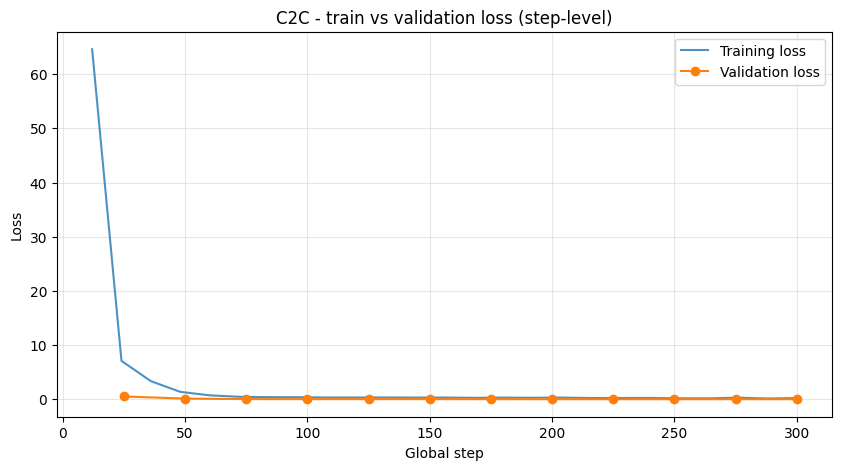

Train log points: 25
Eval log points:  12
Eval step positions: [25, 50, 75, 100, 125, 150, 175, 200, 225, 250] ...


In [15]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# Use global step for clearer trend visibility.
train_losses = [log["loss"] for log in log_history if "loss" in log and "eval_loss" not in log]
train_steps = [log["step"] for log in log_history if "loss" in log and "eval_loss" not in log]

eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
eval_steps = [log["step"] for log in log_history if "eval_loss" in log]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label="Training loss", alpha=0.8)
plt.plot(
    eval_steps,
    eval_losses,
    label="Validation loss",
    marker="o",
    linestyle="-",
    markersize=6,
)
plt.xlabel("Global step")
plt.ylabel("Loss")
plt.title("C2C - train vs validation loss (step-level)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Train log points: {len(train_losses)}")
print(f"Eval log points:  {len(eval_losses)}")
if eval_steps:
    print(f"Eval step positions: {eval_steps[:10]}{' ...' if len(eval_steps) > 10 else ''}")

In [25]:
# Persist adapter + tokenizer (save_model)
OUTPUT_DIR = Path("/kaggle/working/c2c_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(OUTPUT_DIR / "adapter"))
tokenizer.save_pretrained(str(OUTPUT_DIR / "adapter"))
print("Saved to", OUTPUT_DIR / "adapter")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Saved to /kaggle/working/c2c_output/adapter


### Post-training evaluation (structure-first)

Beyond loss: YAML parse rate, schema validity, and simple field matches on a fixed test slice — C2C-specific replacement for “eyeball the outputs” in the food-extract tutorial.

In [ ]:
import random

import torch


def strip_thinking(raw: str) -> str:
    """Drop Gemma thought-channel prefix if present; strip stray markdown fences."""
    raw = raw.strip()
    if "<|channel|>thought" in raw:
        end = raw.rfind("<|channel|>")
        if end != -1:
            raw = raw[end + len("<|channel|>") :].strip()
    if raw.startswith("```"):
        raw = raw[3:]
        if raw.lower().startswith("yaml"):
            raw = raw[4:].lstrip()
        fence = raw.rfind("```")
        if fence != -1:
            raw = raw[:fence].strip()
    return raw


@torch.inference_mode()
def predict_c2c(
    user_text: str,
    max_new_tokens: int = 256,
    debug_raw: bool = False,
) -> str:
    # Match training: same user-side text as apply_gemma_template (via c2c_user_content).
    messages = [
        {"role": "user", "content": c2c_user_content(user_text)},
    ]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(trainer.model.device)
    out = trainer.model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )
    gen = tokenizer.decode(
        out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=False
    )
    if debug_raw:
        print("RAW_GEN (prefix 600 chars):", repr(gen[:600]))
    return strip_thinking(gen)


def metrics_on_test_slice(test_rows, n=50, seed=0):
    rng = random.Random(seed)
    idxs = rng.sample(range(len(test_rows)), min(n, len(test_rows)))
    parse_ok = schema_ok = 0
    is_act_match = intent_match = 0
    task_count_match = 0
    for i in idxs:
        row = test_rows[i]
        pred_raw = predict_c2c(row["text"])
        gold = yaml.safe_load(row["label"])
        try:
            pred = yaml.safe_load(pred_raw)
            parse_ok += 1
        except Exception:
            continue
        ok, _ = validate_c2c_label_obj(pred)
        if ok:
            schema_ok += 1
        if isinstance(pred, dict) and isinstance(gold, dict):
            if pred.get("is_act") == gold.get("is_act"):
                is_act_match += 1
            if pred.get("intent") == gold.get("intent"):
                intent_match += 1
            pt = pred.get("tasks") if isinstance(pred.get("tasks"), list) else []
            gt = gold.get("tasks") if isinstance(gold.get("tasks"), list) else []
            if len(pt) == len(gt):
                task_count_match += 1
    m = len(idxs)
    print(f"Eval on {m} test examples")
    print(f"  YAML parse rate:     {parse_ok/m:.1%}")
    print(f"  Schema-valid rate:   {schema_ok/m:.1%}")
    print(f"  is_act match:        {is_act_match/m:.1%}")
    print(f"  intent match:        {intent_match/m:.1%}")
    print(f"  task-count match:    {task_count_match/m:.1%}")
    return {
        "n": m,
        "parse_ok": parse_ok,
        "schema_ok": schema_ok,
        "is_act_match": is_act_match,
        "intent_match": intent_match,
        "task_count_match": task_count_match,
    }


eval_report = metrics_on_test_slice(test_rows, n=50)

print("\n--- Qualitative examples (5) ---")
for i in range(5):
    row = test_rows[i]
    pred = predict_c2c(row["text"], debug_raw=(i == 0))
    print(f"\n### Example {i}")
    print("INPUT:", row["text"][:400], "..." if len(row["text"]) > 400 else "")
    print("GOLD: ", row["label"][:400])
    print("PRED: ", pred[:400])

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Eval on 50 test examples
  YAML parse rate:     64.0%
  Schema-valid rate:   0.0%
  is_act match:        64.0%
  intent match:        44.0%
  task-count match:    64.0%

--- Qualitative examples (5) ---
RAW_GEN (prefix 600 chars): 'is_act: 1\nintent: log\ntasks:\n  - act: buy groceries for the week\n    who: trainer\n    due: asap\n    pri: H\n  - act: track my weight update\n    who: brother\n    due: after work\n    pri: M\n  - act: message my landlord about the leak\n    who: trainer\n    due: before dinner\n    pri: H<turn|>'

### Example 0
INPUT: brain dump incoming ; can you buy groceries for the week for trainer by asap urgent ; + track my weight updae for brother by after work ; dont let me miss message my landlord about the leak for trainer by before dinner ; also i forgot where i saved the file 
GOLD:  is_act: 1
intent: log
tasks:
- act: buy groceries for the week
  who: trainer
  due: asap
  pri: H
- act: track my weight update
  who: brother
  due: after work
  pri: M
- act

### Save evaluation report & optional Hub push

Write a small JSON report next to the adapter (see `docs/notebook_remaining_steps.md`). Optionally upload the adapter with `huggingface_hub` — mirror of the tutorial’s “upload / Gradio” milestone, deferred until metrics look good.

In [23]:
import json

REPORTS_DIR = OUTPUT_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
report_path = REPORTS_DIR / "c2c_eval_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(eval_report, f, indent=2)
print("Wrote", report_path)

# Optional: push adapter to the Hub (set HUB_REPO_ID and uncomment)
# from huggingface_hub import HfApi
# HUB_REPO_ID = "your-username/c2c-gemma4-e4b-adapter"
# api = HfApi()
# api.upload_folder(folder_path=str(OUTPUT_DIR / "adapter"), repo_id=HUB_REPO_ID, repo_type="model")

Wrote /content/c2c_output/reports/c2c_eval_report.json


### Local M1 check (mlx-lm) — handoff

After Colab: download the folder `c2c_output/adapter` (and this notebook’s `reports/` if you want). On your Mac, use **`mlx-lm`** with a **Gemma 4 E4B** base plus LoRA — see the current [mlx-community Gemma 4 collections](https://huggingface.co/mlx-community) and [mlx-lm docs](https://github.com/ml-explore/mlx-examples/blob/main/llms/README.md).

**Quick checklist**

1. Base model: `google/gemma-4-E4B-it` (or MLX-converted equivalent).
2. Point mlx-lm at your saved **LoRA adapter** directory.
3. Run 10 messy prompts; compare latency and YAML validity vs Colab `predict_c2c` outputs.

### Optional: Gradio demo (tutorial step 6 / `project.md` Spaces path)

Minimal UI to paste messy text and see YAML — same role as the food-extract notebook’s demo, wired to `predict_c2c`.

In [ ]:
# Uncomment to launch a local widget on Colab / Jupyter
# import gradio as gr
#
# demo = gr.Interface(
#     fn=predict_c2c,
#     inputs=gr.Textbox(lines=4, label="Messy message"),
#     outputs=gr.Textbox(lines=12, label="C2C YAML"),
#     title="Chaos-to-Clarity (C2C) Extractor",
# )
# demo.launch(share=True)

## Download

In [26]:
import shutil

shutil.make_archive('/kaggle/working/c2c_output', 'zip', '/kaggle/working/c2c_output')
print('Done! Download c2c_output.zip from the Output panel on the right.')

Done! Download c2c_output.zip from the Output panel on the right.


In [ ]:
from huggingface_hub import HfApi

api = HfApi()
api.upload_file(
    path_or_fileobj="/kaggle/working/c2c_output.zip",
    path_in_repo="c2c_output.zip",
    repo_id="raqibcodes/c2c-checkpoints",
    token="hf_token"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/raqibcodes/c2c-checkpoints/commit/2dc888b128bed5dd26743e467a65bb1cf9e8982f', commit_message='Upload c2c_output.zip with huggingface_hub', commit_description='', oid='2dc888b128bed5dd26743e467a65bb1cf9e8982f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/raqibcodes/c2c-checkpoints', endpoint='https://huggingface.co', repo_type='model', repo_id='raqibcodes/c2c-checkpoints'), pr_revision=None, pr_num=None)

In [ ]:
from huggingface_hub import list_repo_files
for f in list_repo_files("raqibcodes/c2c-checkpoints", token="hf_token"):
    print(f)

.gitattributes
README.md
adapter_config.json
adapter_model.safetensors
c2c_output.zip
chat_template.jinja
checkpoint.zip
last-checkpoint/README.md
last-checkpoint/adapter_config.json
last-checkpoint/adapter_model.safetensors
last-checkpoint/chat_template.jinja
last-checkpoint/optimizer.pt
last-checkpoint/rng_state.pth
last-checkpoint/scheduler.pt
last-checkpoint/tokenizer.json
last-checkpoint/tokenizer_config.json
last-checkpoint/trainer_state.json
last-checkpoint/training_args.bin
tokenizer.json
tokenizer_config.json
training_args.bin
